# **Table of Contents**

> 💡 **Tip:** Use the **Table of Contents** icon (☰) in the left sidebar to quickly jump between sections.

#### 1. **Getting Started**

Start here for an overview of how to use the notebook:

* Understand how to run cells and navigate between sections
* Review the recommended order for using the notebook
* Fusion++ Features

#### 2. **Initial Setup and Authentication**
* Initial setup - when you run the notebook for the very first time.
* Authenticate - Connect with FUSION platform

#### 3. **Data Management Features**
* Download data to Workspace from:
    - HuBMAP data portal
    - Fusion platform
    - local 
* Upload data to the Fusion platform
* Optimize Whole Slide Images

#### 4. **Run Analysis Jobs**
* Available workflows include:
   - Multi-Compartment Segmentation  
   - Frozen Glomerulus Segmentation  
   - Expanded Granular Feature Extraction 
   - Spot Data Generation  
     - Label Transfer  
     - Spot Annotation  
   - Spatial Aggregation

#### 5. **Visualization**
* Visualize HuBMAP Data, analysis results and data on FUSION platform

#### 6. **Metadata Plotting**

# **Getting Started**

This notebook is organized into **simple, collapsible sections** so you can easily navigate it and run only the parts you need. 

> 💡 **Tip:** Use Jupyter Notebook’s built-in Table of Contents icon (☰) in the left sidebar to quickly navigate between sections.

#### Running Cells

* **Shift + Enter** → Run the current cell and move to the next one
* **Ctrl + Enter** → Run the current cell and stay on the same cell

#### Understanding the Sections

* Each section is **independent** and can be run in any order after completing the initial setup
* Within each section, run the cells **from top to bottom**
* Each section is **self-contained** and clearly labeled to guide you through the workflow

> 💡 **Tip:** If you are unsure where to start, follow the steps in order. The notebook is designed to guide you through the process.

#### **Step 1: Initial Setup and Authentication**

Start by running the **Initial Setup and Authentication** section. This installs and imports the required packages and connects the notebook to the FUSION Platform when authentication is required.

> **Note:** Rerun the **Authentication** subsection every time you restart the notebook or kernel.

#### **Step 2: Data Management Features**

If the data-transfer connection does not complete while running the **Download the Dataset to the Workspace** subsection:
1. Click the square **Stop (■)** button in the notebook toolbar to interrupt the running cell.
2. Run the cell again.
3. If the issue continues, restart the kernel using the circular-arrow button and rerun the required authentication cell.

Datasets from sources other than HuBMAP can also be uploaded into the workspace using the **Upload Files** option, or by dragging and dropping the files into the desired folder.

#### **Step 3: Run Analysis Jobs**

Before running an analysis plugin:

* Optimize the whole-slide image by running the **Optimize Whole Slide Images** subsection under **Data Management Features**.
* Make sure the required model and reference files are available in the workspace.
* Download the required files by running code cells **3.1** and **3.2** under the **Download Data from FUSION Platform** subsection in **Data Management Features**.

Choose the segmentation plugin based on the dataset type:

* **Multicompartment Segmentation** works only with **FFPE kidney datasets**.
* **Frozen Glomeruli Segmentation** works only with **frozen kidney datasets**.

> **Important:** Kidney datasets provided by HuBMAP are frozen and should therefore be processed using **Frozen Glomeruli Segmentation**, not **Multicompartment Segmentation**.

#### **Step 4: Visualization**

Use the **Visualization** section to view your dataset and/or analysis outputs. This opens the FUSION Platform’s interactive visualization interface.


#### **Notebook Workflow**

The notebook follows this general workflow:

```text
Initial Setup & Authentication
        ↓
Data Management
(Download / Upload / Prepare Data)
        ↓
Run Analysis Jobs
        ↓
Visualization
```

#### **FUSION++ Features**

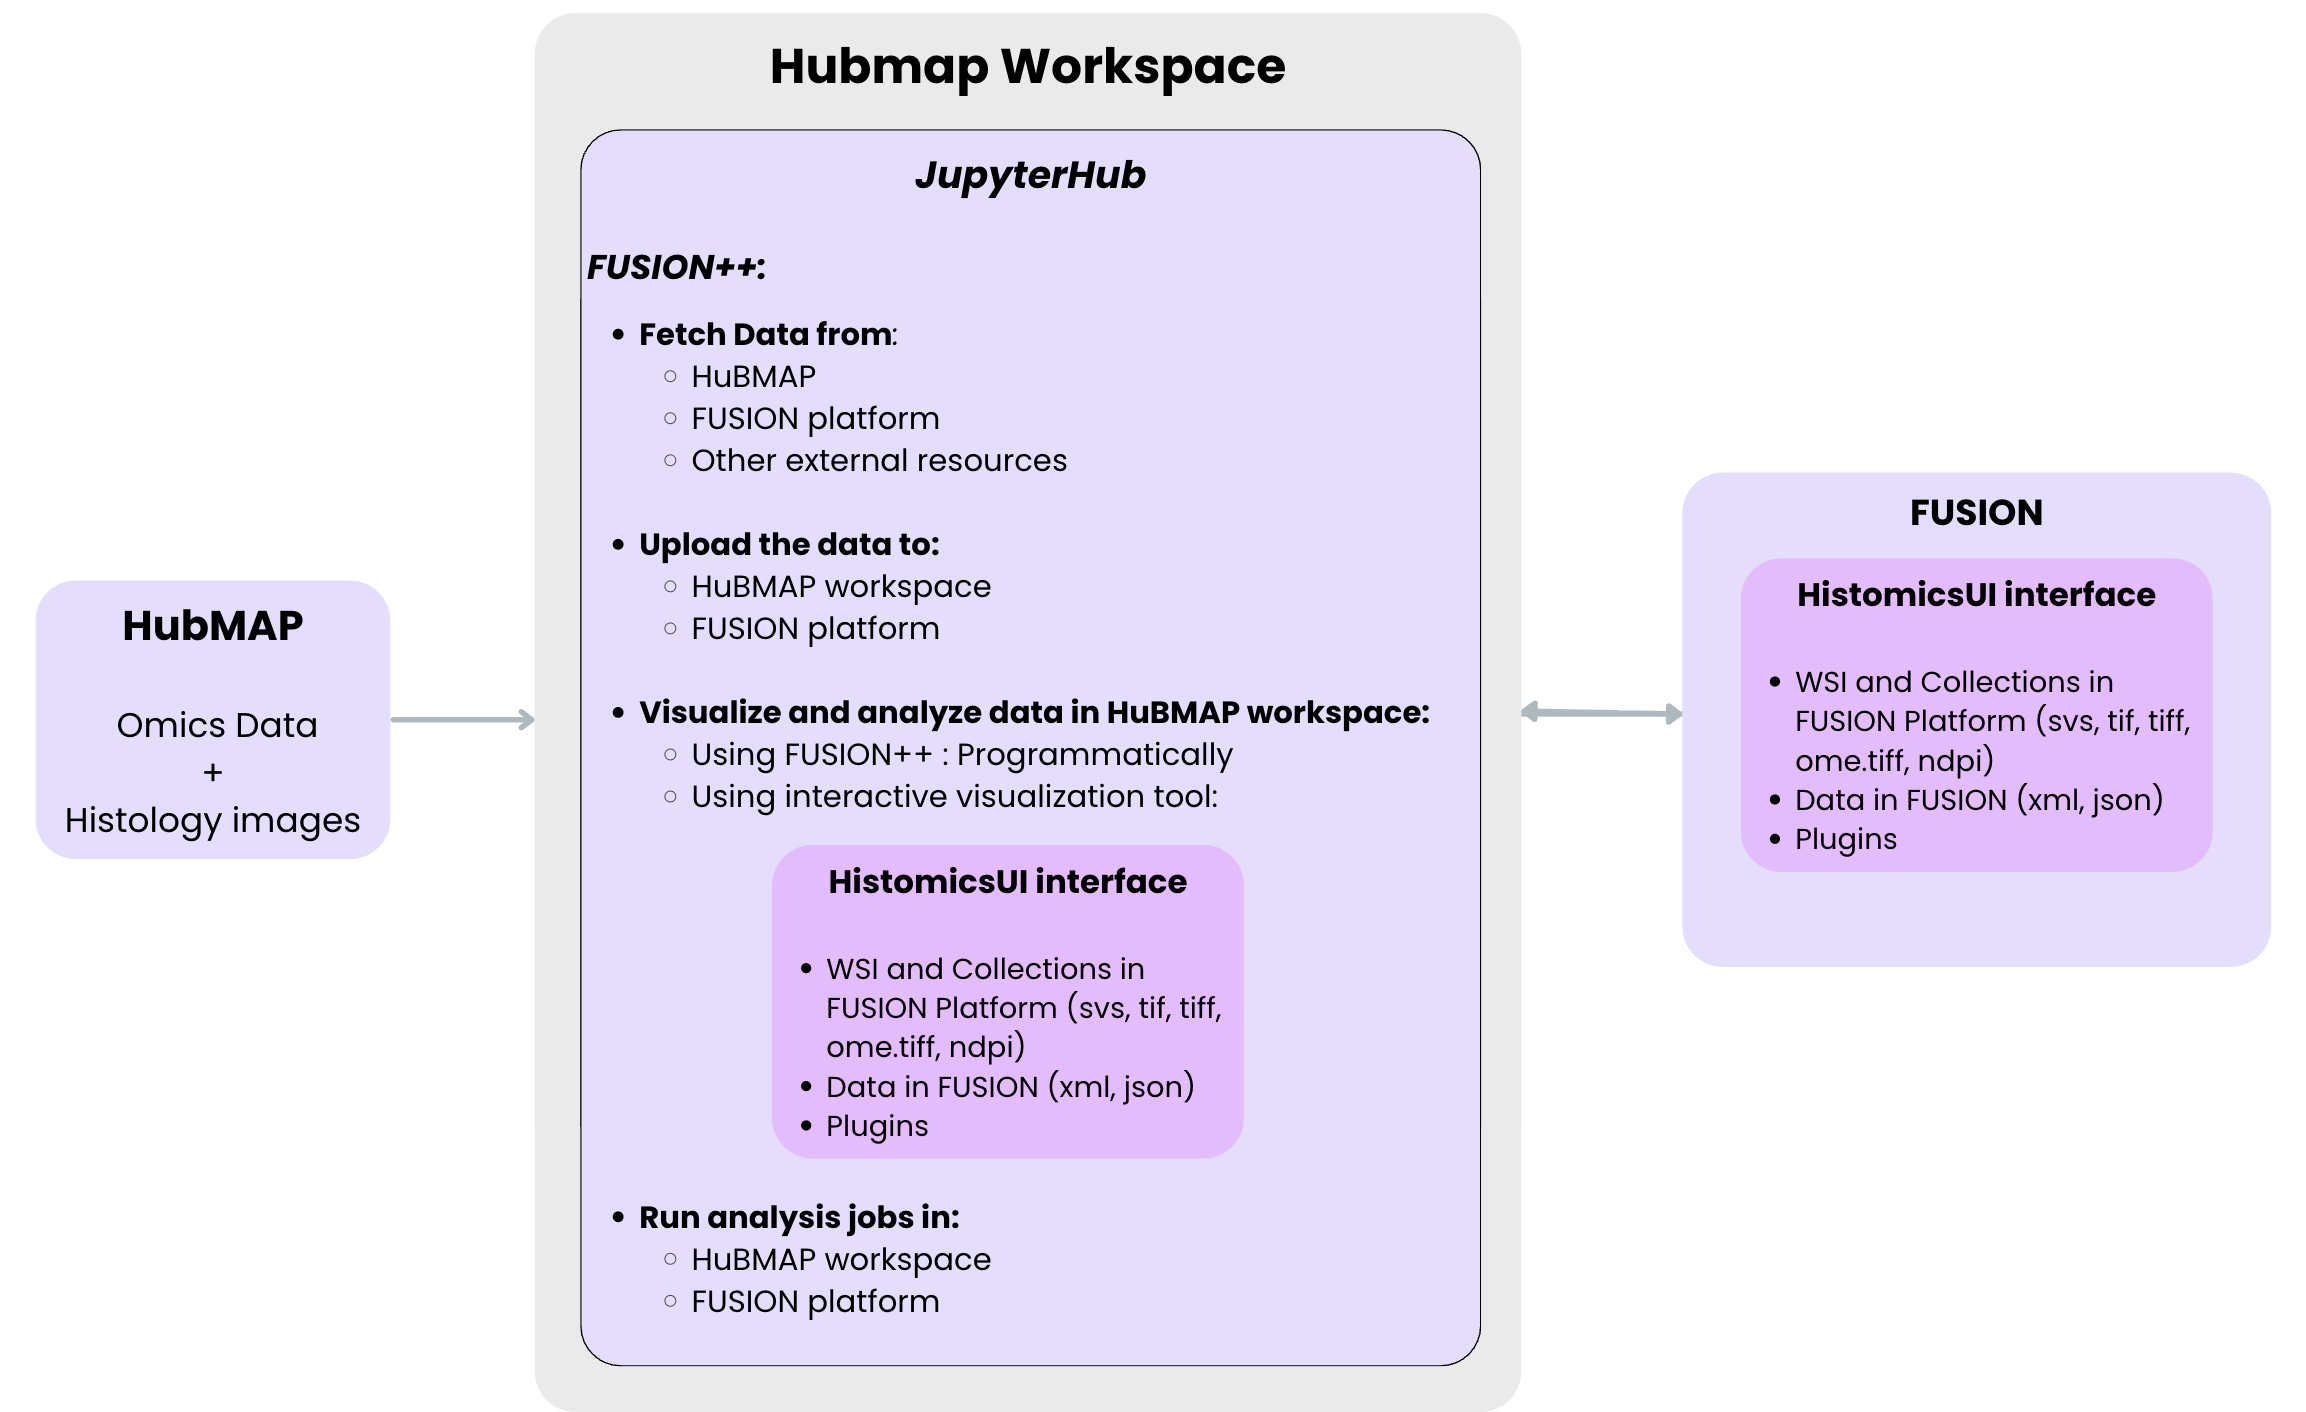

# **Initial Setup and Authentication**

## 1. Initial Setup

In [ ]:
from IPython.display import clear_output

print("⏳ Installing dependencies... this may take a moment.")

!pip install large_image[all] --find-links https://girder.github.io/large_image_wheels
!jupyter server extension enable jupyter_server_proxy

clear_output(wait=True)
print("✅ Installation and setup successful!")

## 2. Authentication

In [ ]:
import getpass

# Authenticate
user_name = input("Enter your username: ")
auth_pass = getpass.getpass("Enter your password: ")

import girder_client
gc = girder_client.GirderClient(apiUrl='https://fusionpub.rc.ufl.edu/api/v1')
try:
    user_info = gc.authenticate(user_name, auth_pass)
    print(f"Login Successful: {user_info['firstName']} {user_info['lastName']} ({user_info['email']})")
except Exception as e:
    print(f"Login Failed: {e}")

# **Data Management Features**

## Overview

This section contains three key features, downloading, uploading and optimizing datasets and related files.

### 1. Download the Dataset to the Workspace

#### 1.1 HuBMAP Portal

This subsection downloads one or more HuBMAP datasets to a directory in the workspace.

**Steps to find a dataset:**

1. **Open the HuBMAP Data Portal:**
   Go to [portal.hubmapconsortium.org](https://portal.hubmapconsortium.org/).
2. **Browse the available datasets:**
   Select **Datasets** from the navigation menu.
3. **Choose a dataset:**
   Browse or search for the dataset or datasets you want to use.
4. **Copy the HuBMAP ID:**
   Each dataset has a unique identifier, such as `HBM123.ABCD.456`.  
   Select **Summary** as shown in the image
   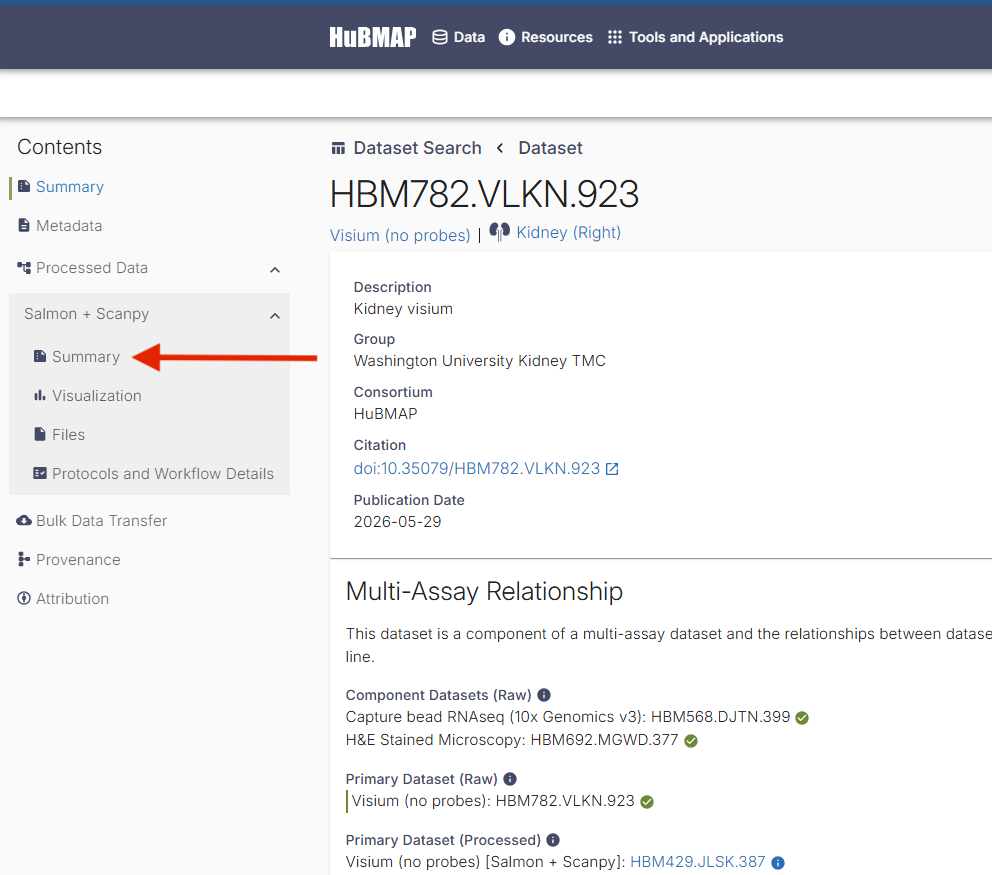
   
   Find the circled ID, copy it and paste it into the `hubmap_id` variable in the code cell below.
   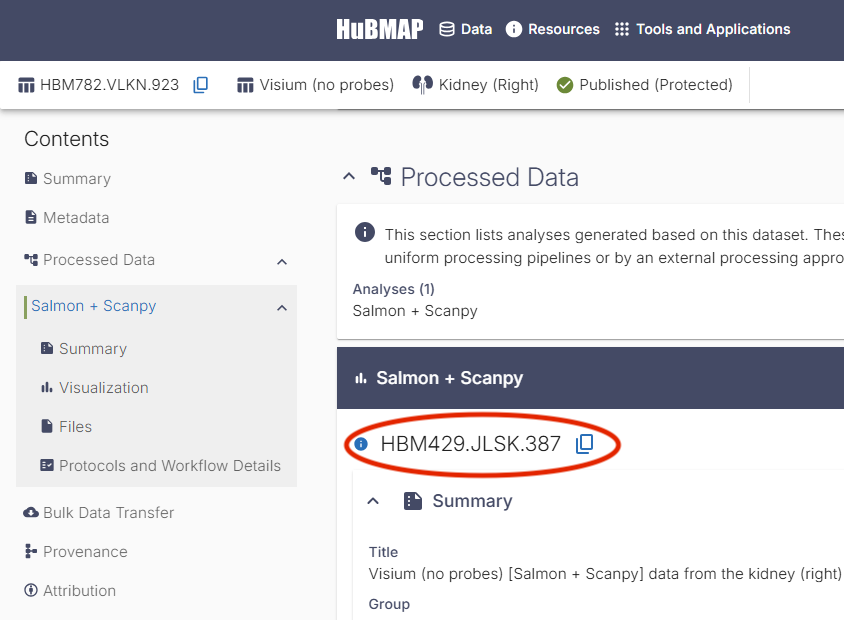
   
Multiple HuBMAP IDs may be provided when downloading more than one dataset.

#### 1.2 FUSION Platform

This subsection downloads a dataset from the FUSION Platform to the workspace.

**Steps to find a dataset:**

1. **Open the FUSIONPUB Portal:**
   Go to [fusionpub.rc.ufl.edu](https://fusionpub.rc.ufl.edu).
2. **Navigate to the kidney datasets:**
   Follow this path:
   `FUSION_Kidney_Visium → Visium → Visium Frozen`
   or
   `FUSION_Kidney_Visium → Visium → Visium FFPE`
3. **Choose a dataset:**
   Browse the available datasets and select the one you want to use.
4. **Copy the Unique ID:**
   Open the **Info** section and copy the value listed as **Unique ID**.
5. **Enter the ID in the notebook:**
   Paste the copied ID into the `resource_id` variable in the **Download Data from FUSION Platform** subsection.

> This subsection also features the code to download predefined model and reference files from FUSION platform which are required for running the analysis pipeline

#### 1.3 Download data from other sources
 - Manually upload it to the left panel (drag and drop)
 - Write your own code to bring data to this workspace from any other resource.

### 2. Upload Data to the FUSION Platform

There are multiple ways to upload data to the FUSION Platform, including manually uploading files through the platform interface.

This subsection provides a direct way to upload data from the workspace to the FUSION Platform.

1. Right-click the desired folder and select **Copy Path**.
2. Paste the copied path into the `dir_path` variable in the notebook.
3. Run the corresponding cell to make the dataset available on the FUSION platform.

### 3. Optimize Whole Slide Images
Use this subsection to optimize whole-slide images before running the analysis plugins.


## 1. Download the Dataset to the Workspace

### 1.1 HuBMAP Portal

- The destination folder will be created automatically if it does not already exist.
- Globus and HuBMAP login may be required before the transfer can begin.
- Globus Connect Personal access is restricted to your current working directory.

| Parameter | Type | Description | Default |
| :--- | :--- | :--- | :--- |
| `destination` | `str` | Local folder where downloaded files will be saved. | `None` |
| `hubmap_id` | `str` | Your selected HuBMAP dataset ID. | *Required* |
| `protected` | `bool` | If True, Download from Protected workspace | `False` |
| `manifest path` | `str` | Path to an existing manifest file instead of providing hubmap_id. | `None` |

In [ ]:
from fusion.utilities.hubmap_data_transfer import transfer
 
destination = 'fusion_demo_notebooks/datasets'

# Replace the placeholders below with the dataset IDs you copied from the HuBMAP Data Portal.
# Example: ["HBM678.GZMT.779", "HBM558.KBHK.745", "HBM494.DCTT.358",
#           "HBM932.WCKN.699", "HBM782.VLKN.923", "HBM375.HFFH.498"]
hubmap_id = ["HBM494.DCTT.358"]  
protected = True
results = transfer(destination=destination, hubmap_id=hubmap_id, protected=protected)

# Note: If GCP fails to connect, interupt the kernel and rerun this cell.

### 1.2 FUSION Platform

#### 1.2.1 Download file, item or folder

| Parameter     | Type   | Description                                                                 |
|--------------|--------|-----------------------------------------------------------------------------|
| `gc`         | object | Girder client instance (required)                                           |
| `resource_id`  | str    | Id of the item or file you want to download                               |
| `resource_type` | str    | 'file' or 'item' or 'folder                                              |
| `output_dir`  | str    | local path to save the file/item                                           |

#### Predefined FUSIONPUB Dataset Folders

You can either provide your own `resource_id` from the FUSIONPUB Portal or use one of the predefined dataset folders listed below.

The table includes **10 FFPE kidney dataset folders** and **10 Frozen kidney dataset folders** available from FUSIONPUB.

| Dataset Type | Folder Name                   | Folder ID                   |
| ------------ | ----------------------------- | --------------------------- |
| Frozen       | `V10S14-085_XY01_20-0038`  | `6a4bdc2d26de63ef5fdd487c`  |
| Frozen       | `V10S14-085_XY02_20-0040`  | `6a4bdc2d26de63ef5fdd487e`  |
| Frozen       | `V10S14-085_XY03_21-0056`  | `6a4bdc2d26de63ef5fdd4880`  |
| Frozen       | `V10S14-085_XY04_21-0057`  | `6a4bdc2e26de63ef5fdd4882`  |
| Frozen       | `V10S14-086_XY01_21-0055`  | `6a4bdc2e26de63ef5fdd4884`  |
| Frozen       | `V10S14-086_XY02_20-0039`  | `6a4bdc2e26de63ef5fdd4886`  |
| Frozen       | `V10S14-086_XY03_21-0063`  | `6a4bdc2e26de63ef5fdd4888`  |
| Frozen       | `V10S14-086_XY04_21-0066`  | `6a4bdc2e26de63ef5fdd488a`  |
| Frozen       | `V10S15-086_XY01_HRT1`     | `6a4bdc2f26de63ef5fdd4894`  |
| Frozen       | `V10S15-086_XY03_HRT3`     | `6a4bdc2f26de63ef5fdd4896`  |
| FFPE         | `V10A14-172_XY01_SLE15`    | `6a4bcf1d26de63ef5fdd468a`    |
| FFPE         | `V10A14-172_XY02_SLE16`    | `6a4bcf1d26de63ef5fdd4690`    |
| FFPE         | `V10A14-172_XY04_SLE18`    | `6a4bcf1d26de63ef5fdd4696`    |
| FFPE         | `V10S15-103_XY01_IU-21-015F` | `6a4bcf1d26de63ef5fdd469c`    |
| FFPE         | `V10S15-103_XY02_IU-21-016F`    | `6a4bcf1d26de63ef5fdd46a2`    |
| FFPE         | `V10S15-103_XY03_IU-21-019F`    | `6a4bcf1d26de63ef5fdd46a8`    |
| FFPE         | `V10S15-103_XY04_IU-21-020F`    | `6a4bcf1d26de63ef5fdd46ae`    |
| FFPE         | `V42D20-364_XY01_2235505`    | `6a4bcf1d26de63ef5fdd46b4`    |
| FFPE         | `V42D20-364_XY04_2240610`    | `6a4bcf1d26de63ef5fdd46ba`    |
| FFPE         | `V42N07-339_XY01_3781`   | `6a4bcf1d26de63ef5fdd46c0`   |

Copy the desired **Folder ID** and paste it into the `resource_id` parameter in the code cell below.


In [ ]:
from fusion import download_from_fusion_to_workspace
download_from_fusion_to_workspace(gc, resource_id='6a4bdc2d26de63ef5fdd487c',resource_type='folder',output_dir='fusion_demo_notebooks/datasets')

#### 1.2.2 Download predefined model_files

In [ ]:
from fusion import download_model_files_from_fusion
download_model_files_from_fusion(gc)

#### 1.2.3 Download predefined reference_files

In [ ]:
from fusion import download_reference_files_from_fusion
download_reference_files_from_fusion(gc)

##  2. Upload Data to the FUSION Platform

| Parameter     | Type   | Description                                                                 |
|--------------|--------|-----------------------------------------------------------------------------|
| `gc`         | object | Girder client instance (required)                                           |                 
| `user`       | str    | Athena username                                                             |
| `file_path`  | str    | Single local file path to upload (for files in the workspace)               |
| `file_paths` | list   | List of local file paths to upload (for multiple files in the workspace)    |
| `dir_path`   | str    | Local directory path; all files in the directory will be uploaded           |
| `all`        | bool   | Download all files from HuBMAP                                              |
| `histology`  | bool   | Download only histology images from HuBMAP                                  |
| `visium`     | bool   | Download only Visium files from HuBMAP                                      |
| `temp_download` | bool | Download to temporary folder and clean up the folder after upload          |
| `folder_id`  | str    | Existing Athena folder ID where you want to upload to                       | 

In [ ]:
from fusion import upload_to_fusion_backend
results = upload_to_fusion_backend(gc, dir_path='fusion_demo_notebooks/datasets/V42D20-364_XY01_2235505.tiff',is_analysis_result= True, user='ashmit.sharma')

##  3. Optimize Whole Slide Images

In [ ]:
from fusion import optimize_workspace_wsi
results = optimize_workspace_wsi('') #Enter path to your folder containing the .tif/.tiff file

# **Run Analysis Jobs**

## Overview

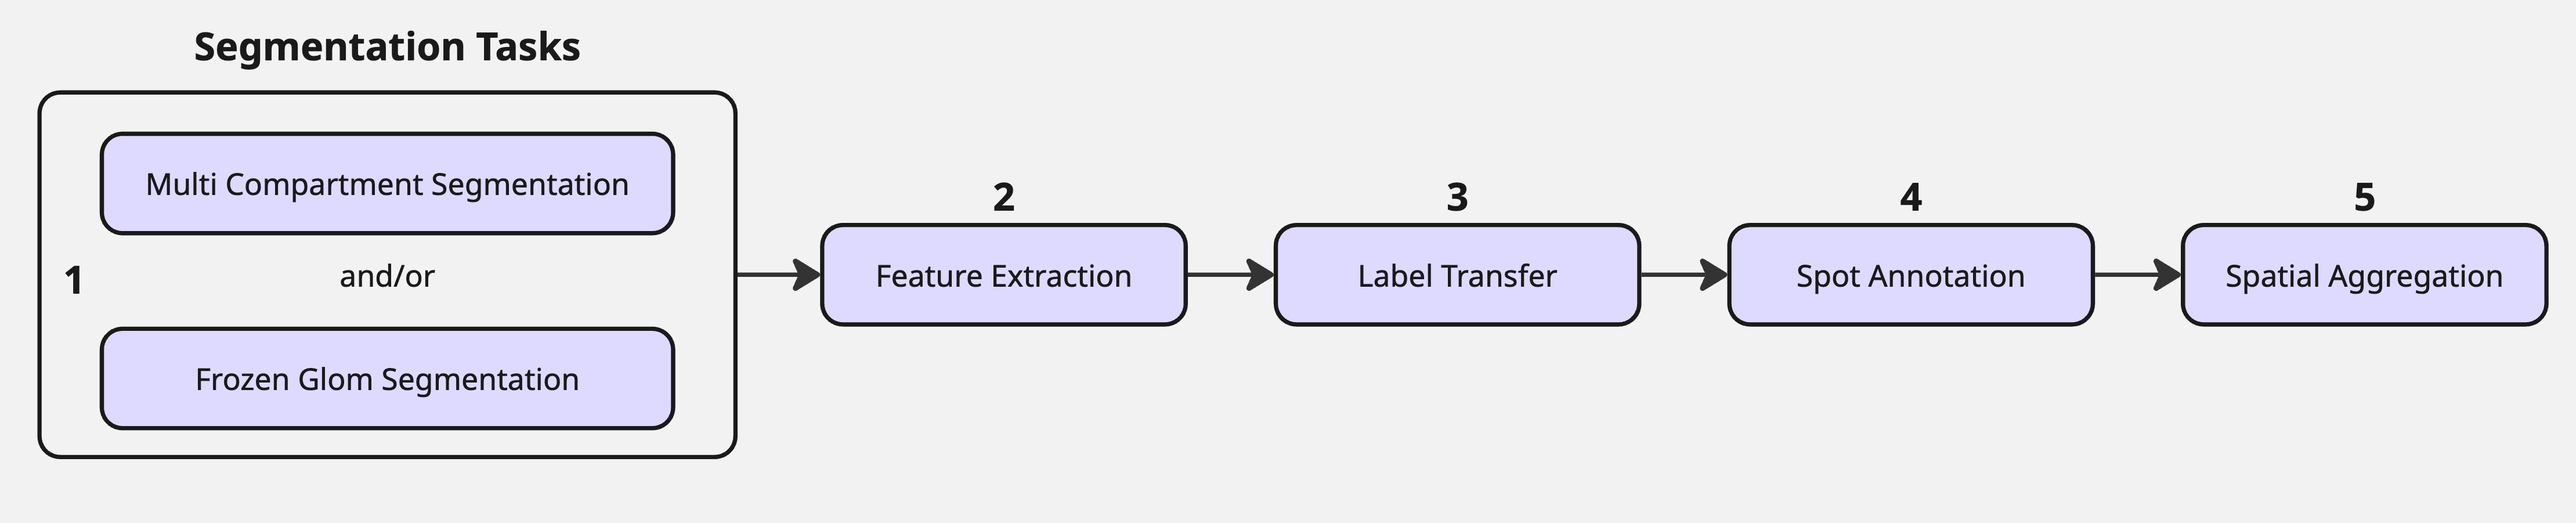


- **Multi-Compartment Segmentation** - Segments WSIs into 6 compartments:
  - Arteries/Arterioles
  - Cortical interstitium
  - Medullary interstitium
  - Non-sclerotic glomerulus
  - Sclerotic glomerulus
  - Tubule
 
- **Frozen Glomerulus Segmentation** - Segments the frozen tissue into glomeruli.
 
- **Expanded Granular Feature Extraction** - Extract 72 morphometric features for each FTU (Functional Tissue Unit)
 
- **Spot Data Generation:**
  - **Label Transfer** - Predicts cell type composition (Main Cell Types - L1/ Sub Cell Types - L2) for each Visium spot using a reference atlas.
  - **Spot Annotation** - Aligns Visium spots to the WSI and embeds cellular information into each spot.
- **Spatial Aggregation** - Aggregates the FTU's with the generated spot data


---
 
**Selecting the Correct Segmentation Job**
 
Choose the segmentation plugin based on the dataset type:
- **Multicompartment Segmentation** works only with **FFPE kidney datasets**.
- **Frozen Glomeruli Segmentation** works only with **frozen kidney datasets**.
 
> **Important:** The kidney dataset provided by **HuBMAP is frozen**. Therefore, it should be processed using **Frozen Glomeruli Segmentation**, not Multicompartment Segmentation.

---


**File Structure Followed for Analysis Function Outputs**

```
fusion_demo_notebooks/
├── fusion_demo.ipynb
└── datasets/
    ├── HuBMAP_ID_1/
    │   ├── (downloaded files: images, h5ad, etc.)
    │   ├── Segmented_FTU/
    │   ├── Aggregated_FTU/
    │   └── Files/
    ├── HuBMAP_ID_2/
    │   ├── (downloaded files: images, h5ad, etc.)
    │   ├── Segmented_FTU/
    │   ├── Aggregated_FTU/
    │   └── Files/
    └── HuBMAP_ID_N/
        ├── (downloaded files: images, h5ad, etc.)
        ├── Segmented_FTU/        # segmentation outputs
        ├── Aggregated_FTU/       # spatial aggregation outputs
        └── Files/                # all other plugin-generated files
```

## Code for Analysis

#### **Parameters for Each Analysis**

| Step | Analysis                    | Parameter              | Description                                                                 |
|------|----------------------------|------------------------|-----------------------------------------------------------------------------|
| 1    | Multicompartment Segmentation | input_file             | Path to the optimized WSI image (e.g. .tif)                                           |
|      |                            | modelfile              | Path to the segmentation model file                                         |
| 2    | Frozen Glom Segmentation   | input_image            | Path to the optimized WSI image                                                       |
|      |                            | model_file             | Path to the segmentation model file                                         |
| 3    | Feature Extraction         | input_image            | Path to the optimized WSI image                                                       |
|      |                            | annotations_dir        | Auto-derived (Segmented_FTU/ under dataset root)                            |
| 4    | Label Transfer            | counts_file            | Path to the 10X Visium counts/expression file (e.g. .h5ad)                  |
|      |                            | reference              | Path to the reference file (e.g. .h5Seurat)                                                |
|      |                            | organ                  | Hardcoded as KPMP Atlas Kidney                                              |
| 5    | Spot Annotation           | image_file             | Path to the WSI image (used only to locate dataset root)                    |
|      |                            | cell_reference_file    | Path to the cell reference file                                             |
| 6    | Spatial Aggregation       | base_annotation        | Path to the base annotation file (Spots.json)                                           |
|      |                            | agg_annotations        | One or more annotation paths (space-separated)                              |

#### **Run the Analysis Function**

Use `run_analysis()` to launch any analysis task. Choose where you want to run the analyses:

| Parameter | Description |
|---|---|
| `'notebook'` | Runs the analysis on the HuBMAP Workspace. |
| `'fusion'` | Runs the analysis on the Fusion Platform. Requires `gc` and `user_name`. |

To run in the HuBMAP Workspace: 
`run_analysis('notebook')`
> Note: To download the default Model and Reference files use: `run_analysis('notebook', gc=gc)`

To run on the Fusion Platform:
`run_analysis('fusion', gc=gc, user_name=user_name)`

In [ ]:
from fusion import run_analysis

results = run_analysis('notebook')

#### **Job Status**



| Code to Run | Description |
|---|---|
| `check_job_status()` | Helps the user see the status of all submitted jobs in a live-refreshing view |
| `check_job_status(mode='live')` | Shows a live-refreshing status view of all submitted jobs every 2 seconds |
| `check_job_status('{job_id}', 'live_logs')` | Helps the user see the logs for the job_id mentioned |

- job_id → The unique identifier of the job you want to monitor
- 'live' → Prints and Refreshes the job status table every 2 seconds
- 'live_logs' → Streams real-time logs/output for one specific job

> All the logs can be found under: *fusion_demo_notebooks/datasets/{_hubmap_id_of_image}/logs*

In [ ]:
from fusion import check_job_status

check_job_status()

# **Visualization**

Use `visualize_wsi()` to visualise data in the FUSION interface.

| Parameter | Type | Description | Required |
|-----------|------|-------------|----------|
| `gc` | object | Girder client instance (only needed when using Fusion Platform) | Yes |
| `item_id` | str | Unique FUSION item ID assigned to an uploaded file. It can be found in the file's details on fusionpub platform under 'Unique ID'. Use this to visualize a specific file already uploaded to fusionpub | `item_id` (Only needed when using Fusion Platform) |
| `user` | str | Username for authentication | Yes (except when using `item_id`) |
| `dir_path` | str | Local directory path containing WSI or Visium-related output. | Required if not using `item_id`|

> This tool can also be used to navigate the files in the Fusion Platform

To open up visual tool: `visualize_wsi(gc, user=user_name)` 

To visualise a specific item from Fusion: `visualize_wsi(gc, item_id='your_item_id', user='user_name')`

To visualise data from local directory: `visualize_wsi(gc, dir_path='/path/to/your/dataset_directory', user='user_name')`

In [ ]:
from fusion.utilities.visualize import visualize_wsi

result = visualize_wsi(gc, dir_path='fusion_demo_notebooks/datasets/V42D20-364_XY01_2235505.tiff', user=user_name)
result

# **Metadata Plotting**

In [ ]:
import pandas as pd

import numpy as np

import scanpy as sc

import anndata as ad

import json

import os

from pydeseq2.dds import DeseqDataSet

from pydeseq2.ds import DeseqStats

import matplotlib.pyplot as plt

import seaborn as sns
 
# =============================================================================

# SECTION 1: Parse the Barcode-to-Case CSV

# =============================================================================

csv_path = "/hive/user-workspaces/injarapu/1843/Metadata_plot/barcode-and-case.csv"

# Load CSV and drop unassigned cases [1, 2]

barcode_case = pd.read_csv(csv_path).dropna(subset=['Case'])

barcode_case = barcode_case[barcode_case['Case'] != ""]
 
# Recover true barcodes by stripping Loupe suffixes (-1/-2) [2, 3]

def get_true_barcode(bc):

    return bc.rsplit('-', 1)[0] + "-1"
 
barcode_case['true_barcode'] = barcode_case['Barcode'].apply(get_true_barcode)

barcode_case['condition'] = np.where(barcode_case['Case'].str.contains('control'), 'control', 'active_amr')
 
# Split for lookup [4]

amr_lookup = barcode_case[barcode_case['condition'] == 'active_amr'].set_index('true_barcode')

ctrl_lookup = barcode_case[barcode_case['condition'] == 'control'].set_index('true_barcode')
 
# =============================================================================

# SECTION 2: Helper Function -- Parse FUSION JSON

# =============================================================================

def parse_glom_json(json_path, condition_label):

    with open(json_path, 'r') as f:

        data = json.load(f)

    glom_records = []

    # Extract structure instances and their associated barcodes [4, 5]

    for i, element in enumerate(data['annotation']['elements']):

        struct_id = f"Glomerulus_{i+1}_{condition_label}"

        # Adjust the key 'points' or 'barcodes' based on your JSON structure [5]

        barcodes = element['user']['barcode_Aggregated'].get('Count', []) 

        for bc in barcodes:

            glom_records.append({'barcode': bc, 'structure_id': struct_id})

    return pd.DataFrame(glom_records)
 
# =============================================================================

# SECTION 3 & 4: Load Data and Annotate [6, 7]

# =============================================================================

# Loading pre-converted h5ad files

adata_amr = sc.read_h5ad("/hive/user-workspaces/injarapu/1843/Metadata_plot/chen-LLU-active-amr-visium_integrated.h5ad")

adata_ctrl = sc.read_h5ad("/hive/user-workspaces/injarapu/1843/Metadata_plot/chen-LLU-control-visium_integrated.h5ad")
 
def annotate_adata(adata, lookup_df, condition):

    # Map case_id and condition [8]

    adata.obs['case_id'] = adata.obs_names.map(lookup_df['Case'])

    adata.obs['condition'] = condition

    return adata
 
adata_amr = annotate_adata(adata_amr, amr_lookup, "active_amr")

adata_ctrl = annotate_adata(adata_ctrl, ctrl_lookup, "control")
 
# Load Glomerular Maps [9]

amr_glom_map = parse_glom_json("/hive/user-workspaces/injarapu/1843/Metadata_plot/agg_non_globally_sclerotic_glomeruliactive_AMR.json", "amr")

ctrl_glom_map = parse_glom_json("/hive/user-workspaces/injarapu/1843/Metadata_plot/agg_non_globally_sclerotic_glomeruli_control.json", "ctrl")
 
# =============================================================================

# SECTION 5 & 6: Subset and Pseudo-Bulk Aggregation

# =============================================================================

def get_glom_pseudobulk(adata, glom_map):

    # Subset to glomerular spots with valid case IDs [10, 11]

    adata.obs['structure_id'] = adata.obs_names.map(glom_map.set_index('barcode')['structure_id'])

    subset = adata[adata.obs['structure_id'].notna() & adata.obs['case_id'].notna()].copy()

    print(subset)

    # Aggregate counts (sum) by structure_id [12, 13]

    # In Scanpy, we can use the following to get a new AnnData of summed counts

    pb_adata = ad.AnnData(

        X = pd.DataFrame(subset.X.toarray(), index=subset.obs_names, columns=subset.var_names)

            .groupby(subset.obs['structure_id']).sum(),

        var = subset.var

    )

    # Carry over metadata

    pb_metadata = subset.obs[['structure_id', 'condition', 'case_id']].drop_duplicates().set_index('structure_id')

    pb_adata.obs = pb_metadata.loc[pb_adata.obs_names]

    return pb_adata
 
pb_amr = get_glom_pseudobulk(adata_amr, amr_glom_map)

pb_ctrl = get_glom_pseudobulk(adata_ctrl, ctrl_glom_map)
 
# Combine datasets [14]

pb_combined = ad.concat([pb_amr, pb_ctrl])
 
# =============================================================================

# SECTION 8: PyDESeq2 Analysis [15-17]

# =============================================================================

# Filter low-count genes (sum across all samples >= 10)

sc.pp.filter_genes(pb_combined, min_counts=10)
 
# Initialize DESeq2 object

# PyDESeq2 requires raw counts in integer format

dds = DeseqDataSet(

    counts=pd.DataFrame(pb_combined.X.astype(int), index=pb_combined.obs_names, columns=pb_combined.var_names),

    metadata=pb_combined.obs,

    design_factors="condition",

    refit_cooks=True

)
 
dds.deseq2()
 
# Extract results (Active AMR vs Control)

stat_res = DeseqStats(dds, contrast=["condition", "active_amr", "control"])

stat_res.summary()

de_df = stat_res.results_df
 

In [ ]:
de_df = pd.read_csv("/hive/user-workspaces/injarapu/1843/Metadata_plot/DE_ActiveAMR_vs_Control_Glomeruli.csv")

import matplotlib.pyplot as plt
import numpy as np
 
# Create significance column
def assign_significance(row):
    if row['padj'] < 0.05 and row['log2FoldChange'] > 1:
        return "Up in Active AMR"
    elif row['padj'] < 0.05 and row['log2FoldChange'] < -1:
        return "Up in Control"
    else:
        return "Not Significant"
 
de_df['significance'] = de_df.apply(assign_significance, axis=1)
 
# Get top 15 genes for labeling
top_label_genes = de_df[de_df['padj'] < 0.05].head(15)
 
# Create the volcano plot
fig, ax = plt.subplots(figsize=(9, 7))
 
# Define colors
colors = {
    "Up in Active AMR": "#E63946",
    "Up in Control": "#457B9D", 
    "Not Significant": "grey"
}
 
# Plot points by significance group
for sig_type, color in colors.items():
    subset = de_df[de_df['significance'] == sig_type]
    ax.scatter(subset['log2FoldChange'], -np.log10(subset['padj']), 
              c=color, alpha=0.6, s=15, label=sig_type)
 
# Add threshold lines
ax.axhline(y=-np.log10(0.05), color='grey', linestyle='--', alpha=0.7)
ax.axvline(x=-1, color='grey', linestyle='--', alpha=0.7)
ax.axvline(x=1, color='grey', linestyle='--', alpha=0.7)
 
# Add gene labels for top genes (using actual gene names from index)
for idx, row in top_label_genes.iterrows():
    ax.annotate(row['gene'], (row['log2FoldChange'], -np.log10(row['padj'])), 
                xytext=(5, 5), textcoords='offset points', 
                fontsize=8, alpha=0.8)
 
# Add legend at the top
legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.02), 
                  ncol=3, frameon=False, fontsize=10)
 
# Customize plot
ax.set_xlabel('log2 Fold Change (Active AMR / Control)', fontsize=12)
ax.set_ylabel('-log10(Adjusted P-Value)', fontsize=12)
ax.set_title('Glomerular DE: Active AMR vs. Control', fontsize=14, pad=40)
ax.text(0.5, 0.95, 'Each pseudo-bulk sample = one individual glomerulus | padj < 0.05, |log2FC| > 1', 
        transform=ax.transAxes, ha='center', fontsize=10, style='italic')
 
# Clean up plot appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("volcano_ActiveAMR_vs_Control_Glomeruli.pdf", dpi=300, bbox_inches='tight')
plt.show()

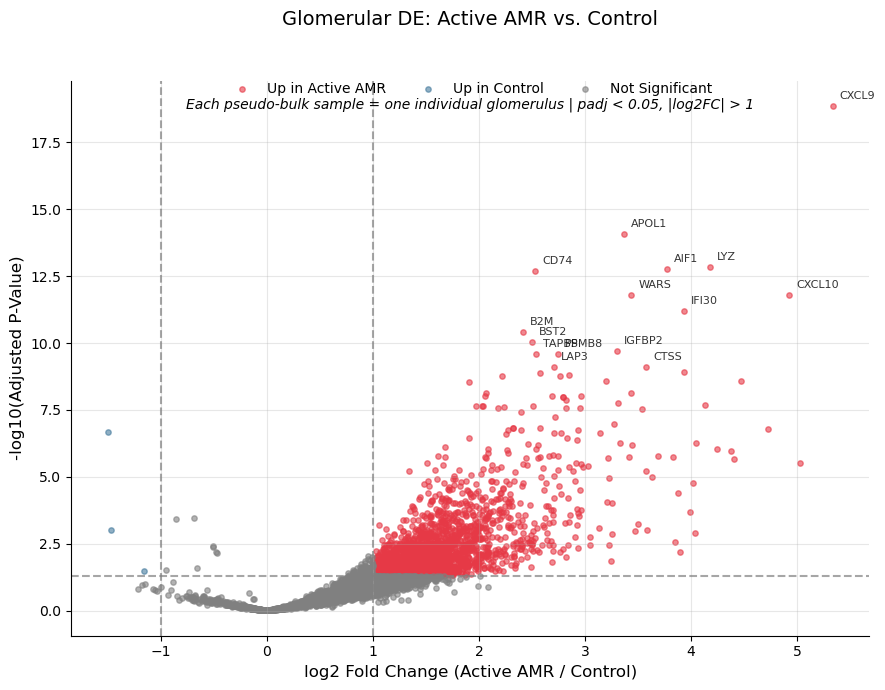

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
 
# =============================================================================
# SECTION 10: Heatmap of Top 20 DE Genes
# =============================================================================
 
# Top 20 genes
top20_genes = (
    de_df.loc[~de_df["padj"].isna()]
         .head(20)["gene"]
         .tolist()
)
sample_metadata = pd.read_csv("/hive/user-workspaces/injarapu/1815/LLU_plotting_input/output/sample_metadata_renamed.csv", index_col=0)
# Variance-stabilizing transformation (approximation)
vst_data = dds.copy()
sc.pp.normalize_total(vst_data, target_sum=1e4)
sc.pp.log1p(vst_data)
 
# Extract matrix
heatmap_mat = vst_data[:, top20_genes].X.T
 
# Convert to DataFrame for easier handling
heatmap_mat = pd.DataFrame(
    heatmap_mat,
    index=top20_genes,
    columns=vst_data.obs_names
)
 
# Scale each gene (row-wise z-score)
heatmap_mat_scaled = heatmap_mat.sub(heatmap_mat.mean(axis=1), axis=0) \
                               .div(heatmap_mat.std(axis=1), axis=0)
 
# Column annotationvv
col_annotation = pd.DataFrame({
    "Condition": sample_metadata.loc[heatmap_mat_scaled.columns, "condition"],
    "Donor": sample_metadata.loc[heatmap_mat_scaled.columns, "case_id"]
})
 
# Annotation colors
annotation_colors = {
    "active_amr": "#E63946",
    "control": "#457B9D"
}
 
# Map colors for seaborn
col_colors = col_annotation["Condition"].map(annotation_colors)
 
# Custom heatmap colormap
cmap = LinearSegmentedColormap.from_list(
    "custom",
    ["#313695", "white", "#A50026"]
)
 
# Plot heatmap
heatmap_obj = sns.clustermap(
    heatmap_mat_scaled,
    row_cluster=True,
    col_cluster=True,
    col_colors=col_colors,
    cmap=cmap,
    xticklabels=True,
    yticklabels=True,
    figsize=(12, 8)
)
 
plt.title("Top 20 DE Genes: Active AMR vs. Control Glomeruli")
 
# Save to PDF
plt.savefig("heatmap_top20_ActiveAMR_vs_Control_Glomeruli.pdf")
 
plt.show()

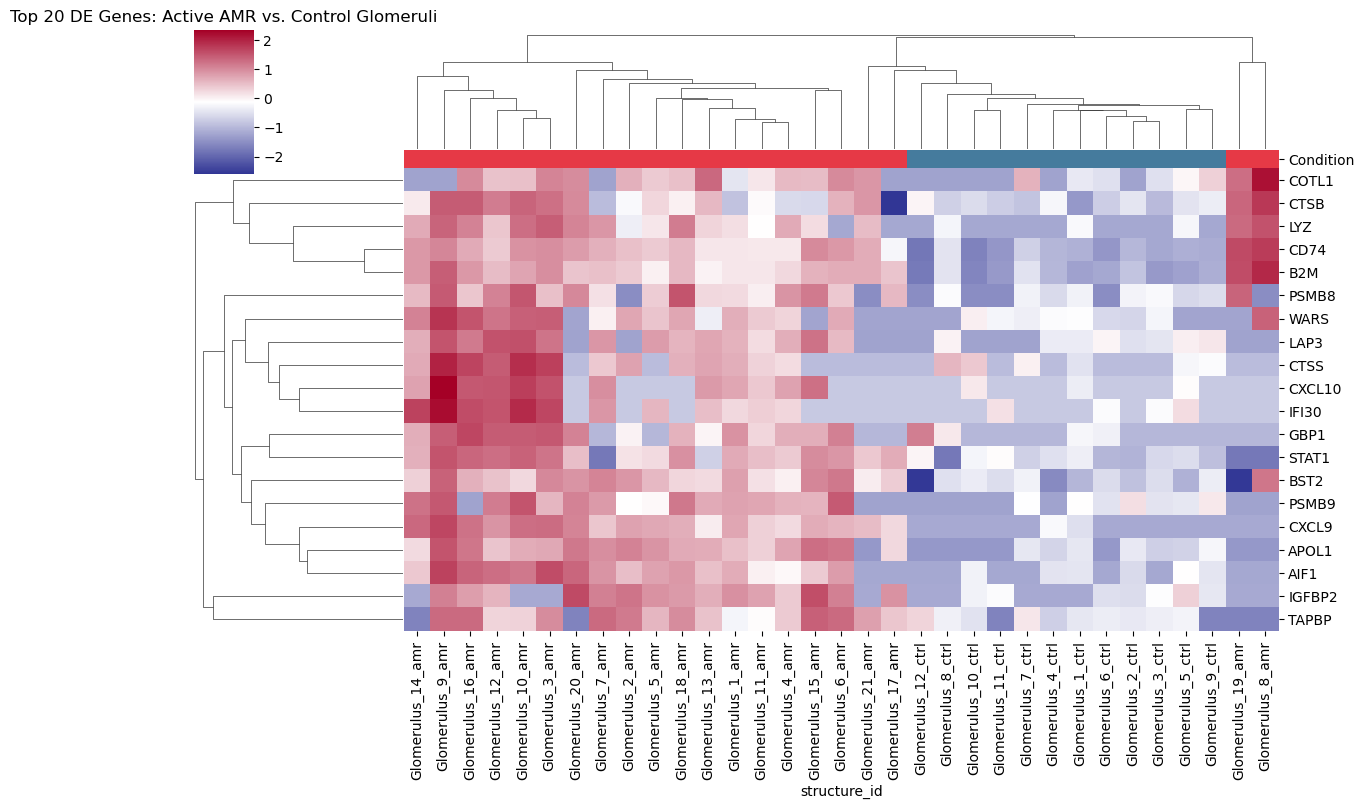


### Summary:
- All data added to the workspace is persisted, so it remains available when you return.
- The notebook preserves its current state, including outputs, making it easy to share workflows, while keeping your data private.
- With integrated flowcharts and documentation, it serves as an effective tool for teaching.
- With a code-based environment and available FUSION++ features, it provides a flexible platform to bring your own data, perform custom analyses, create visualizations, and build workflows tailored to your needs.